In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("data/flights_cleaned.csv")
df.head()

C:\Users\Asus\AppData\Local\Temp\ipykernel_12260\3795264085.py:4: DtypeWarning: Columns (0: CANCELLATION_REASON) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data/flights_cleaned.csv")


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,MONTH_NAME,DAY_NAME,DEPARTURE_HOUR,ROUTE
0,2015,4,7,2,EV,4900,N759EV,FWA,DTW,1340,...,NaN,0.0,0.0,0.0,0.0,0.0,April,Tuesday,13,FWA-DTW
1,2015,1,24,6,AS,611,N413AS,LAS,SEA,1910,...,NaN,0.0,0.0,0.0,0.0,0.0,January,Saturday,19,LAS-SEA
2,2015,7,8,3,WN,1483,N463WN,OAK,SEA,630,...,NaN,0.0,0.0,0.0,0.0,0.0,July,Wednesday,6,OAK-SEA
3,2015,5,26,2,WN,193,N7745A,STL,DAL,810,...,NaN,0.0,0.0,0.0,152.0,0.0,May,Tuesday,8,STL-DAL
4,2015,7,6,1,UA,253,N213UA,IAH,HNL,1000,...,NaN,0.0,0.0,0.0,0.0,0.0,July,Monday,10,IAH-HNL


In [22]:
top_routes = df["ROUTE"].value_counts().head(10)

print(top_routes)

ROUTE
SFO-LAX    1375
LAX-SFO    1347
LAX-JFK    1240
JFK-LAX    1197
LAS-LAX     985
LAX-LAS     959
LGA-ORD     928
ORD-LGA     926
JFK-SFO     881
OGG-HNL     865
Name: count, dtype: int64


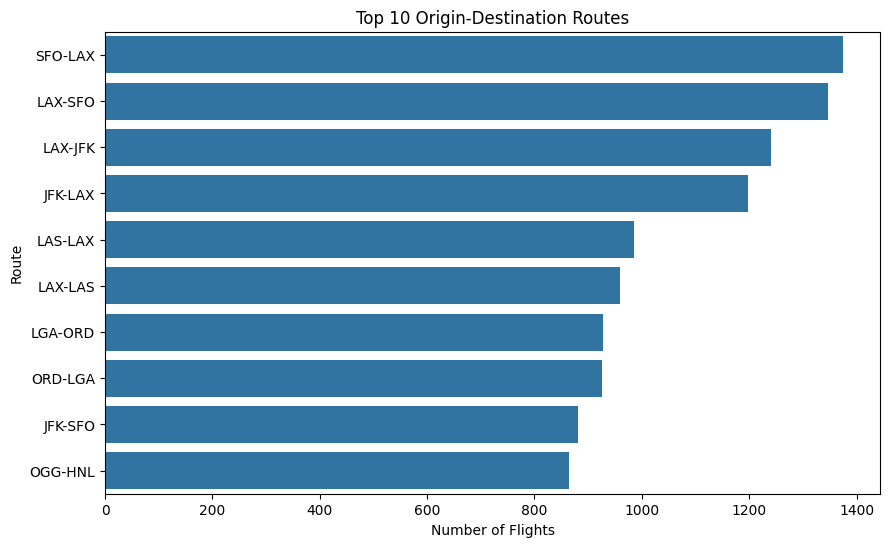

In [23]:
plt.figure(figsize=(10,6))

sns.barplot(x=top_routes.values, y=top_routes.index)

plt.title("Top 10 Origin-Destination Routes")
plt.xlabel("Number of Flights")
plt.ylabel("Route")

plt.show()

In [24]:
df_airports = df[df["ORIGIN_AIRPORT"].astype(str).str.isalpha()]
top_airports = df["ORIGIN_AIRPORT"].value_counts().head(10).index
df_top = df[df["ORIGIN_AIRPORT"].isin(top_airports)]
top_routes = df_top["ROUTE"].value_counts().head(15).index
df_top_routes = df_top[df_top["ROUTE"].isin(top_routes)]
delay_pivot = df_top_routes.pivot_table(
    values="DEPARTURE_DELAY",
    index="ORIGIN_AIRPORT",
    columns="DESTINATION_AIRPORT",
    aggfunc="mean"
)
delay_pivot = delay_pivot.fillna(0)
print(delay_pivot)

DESTINATION_AIRPORT        JFK        LAS        LAX        LGA      MCO  \
ORIGIN_AIRPORT                                                             
ATL                   0.000000   0.000000   0.000000  13.257073  9.92823   
DFW                   0.000000   0.000000   0.000000   0.000000  0.00000   
LAS                   0.000000   0.000000  10.996933   0.000000  0.00000   
LAX                  12.256702  10.575630   0.000000   0.000000  0.00000   
ORD                   0.000000   0.000000  14.019380  15.356659  0.00000   
SFO                  12.776840   9.340686  13.779192   0.000000  0.00000   

DESTINATION_AIRPORT        ORD        PHX       SEA        SFO  
ORIGIN_AIRPORT                                                  
ATL                   0.000000   0.000000  0.000000   0.000000  
DFW                  11.957219   0.000000  0.000000   0.000000  
LAS                   0.000000   0.000000  0.000000   0.000000  
LAX                  12.201456  12.175766  4.856226  15.045038  
O

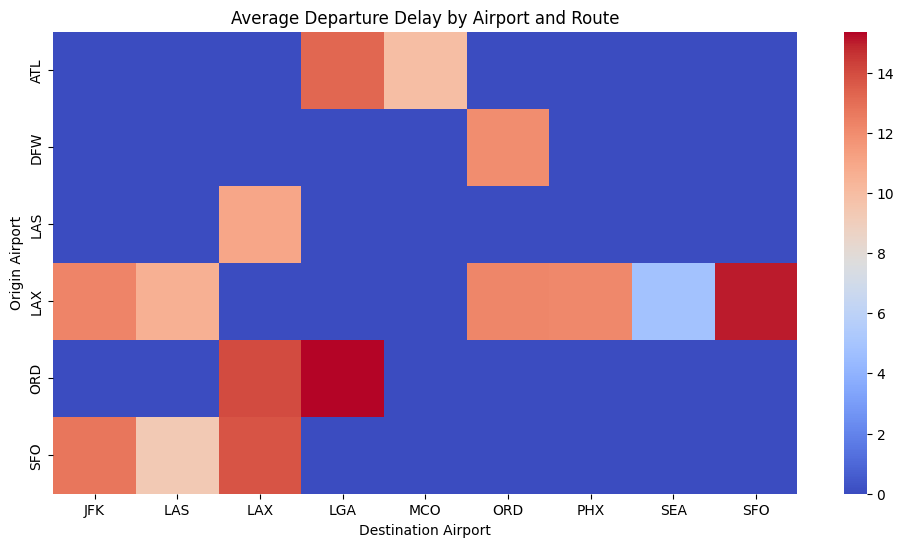

In [25]:
plt.figure(figsize=(12,6))

sns.heatmap(delay_pivot, cmap="coolwarm")

plt.title("Average Departure Delay by Airport and Route")
plt.xlabel("Destination Airport")
plt.ylabel("Origin Airport")

plt.show()

In [27]:
import pandas as pd
import plotly.express as px

airport_coords = {
    "ATL": [33.6407, -84.4277],
    "LAX": [33.9416, -118.4085],
    "JFK": [40.6413, -73.7781],
    "ORD": [41.9742, -87.9073],
    "DFW": [32.8998, -97.0403],
    "DEN": [39.8561, -104.6737],
    "SFO": [37.6213, -122.3790],
    "LAS": [36.0840, -115.1537],
    "SEA": [47.4502, -122.3088],
    "PHX": [33.4342, -112.0116]
}

# Top 10 busiest airports
airport_counts = df["ORIGIN_AIRPORT"].value_counts().head(10)

# Average delay
airport_delay = df.groupby("ORIGIN_AIRPORT")["DEPARTURE_DELAY"].mean()

# Create dataframe
airport_data = pd.DataFrame({
    "airport": airport_counts.index,
    "flights": airport_counts.values,
    "avg_delay": airport_delay[airport_counts.index].values
})

airport_data = airport_data[airport_data["airport"].isin(airport_coords.keys())]

airport_data["lat"] = airport_data["airport"].apply(lambda x: airport_coords[x][0])
airport_data["lon"] = airport_data["airport"].apply(lambda x: airport_coords[x][1])
# Create map
fig = px.scatter_geo(
    airport_data,
    lat="lat",
    lon="lon",
    size="flights",
    color="avg_delay",
    hover_name="airport",
    scope="usa",
    title="Busiest Airports and Average Delays"
)

fig.show()

In [28]:
import calendar
monthly_cancellations = df.groupby("MONTH")["CANCELLED"].sum()
monthly_cancellations = monthly_cancellations.reset_index()

monthly_cancellations["MONTH"] = monthly_cancellations["MONTH"].apply(lambda x: calendar.month_name[x])
fig = px.line(
    monthly_cancellations,
    x="MONTH",
    y="CANCELLED",
    markers=True,
    title="Monthly Flight Cancellation Trends"
)

fig.show()

In [37]:
cancelled_flights = df[df["CANCELLED"] == 1]
cancellation_counts = cancelled_flights["CANCELLATION_REASON"].value_counts()
reason_map = {
    "A": "Carrier",
    "B": "Weather",
    "C": "NAS",
    "D": "Security"
}

cancellation_counts.index = cancellation_counts.index.map(reason_map)
cancellation_counts = cancellation_counts.reset_index()
cancellation_counts.columns = ["Reason", "Count"]
print(cancellation_counts)

     Reason  Count
0   Weather   4890
1   Carrier   2543
2       NAS   1616
3  Security      3


In [38]:
import plotly.express as px

fig = px.pie(
    cancellation_counts,
    names="Reason",
    values="Count",
    title="Flight Cancellation Reasons"
)

fig.show()

In [44]:
# Average delay by month
monthly_delay = df.groupby('MONTH')['ARRIVAL_DELAY'].mean()

print(monthly_delay)

MONTH
1     5.688256
2     8.310048
3     4.724340
4     3.538466
5     4.552207
6     9.554415
7     6.786311
8     4.543492
9    -0.797162
10   -0.537215
11    0.904588
12    6.308776
Name: ARRIVAL_DELAY, dtype: float64


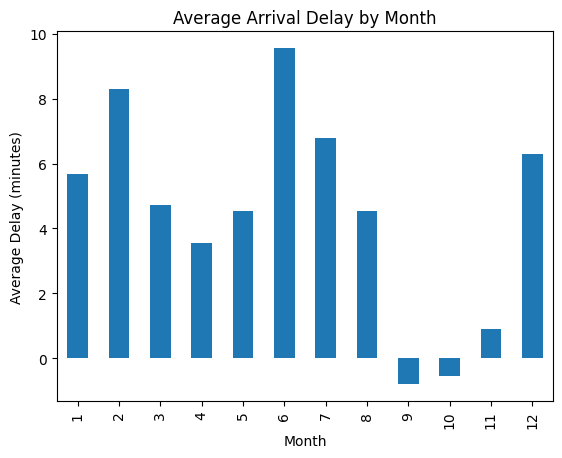

In [45]:
import matplotlib.pyplot as plt

monthly_delay.plot(kind='bar')
plt.title("Average Arrival Delay by Month")
plt.xlabel("Month")
plt.ylabel("Average Delay (minutes)")
plt.show()

In [46]:
winter = df[df['MONTH'].isin([12,1,2])]

winter_delay = winter['ARRIVAL_DELAY'].mean()

print("Average Winter Delay:", winter_delay)

Average Winter Delay: 6.709740167436014


In [47]:
overall_delay = df['ARRIVAL_DELAY'].mean()

print("Overall Average Delay:", overall_delay)

Overall Average Delay: 4.454959012387057


In [50]:
winter_cancel = df[df['MONTH'].isin([12,1,2])]['CANCELLED'].mean()

print("Winter Cancellation Rate:", winter_cancel)
winter_cancel_percentage=round(winter_cancel*100,2)
print("Cancelled flights in winter",winter_cancel_percentage,"%")

Winter Cancellation Rate: 0.029993613747859155
Cancelled flights in winter 3.0 %


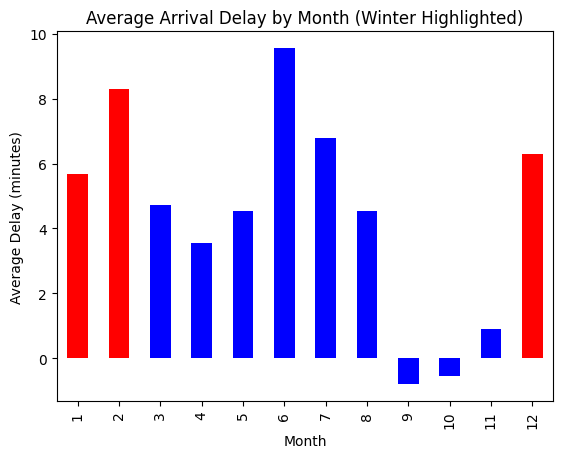

In [52]:
winter_months = [12,1,2]

colors = ['red' if m in winter_months else 'blue' for m in monthly_delay.index]

monthly_delay.plot(kind='bar', color=colors)

plt.title("Average Arrival Delay by Month (Winter Highlighted)")
plt.xlabel("Month")
plt.ylabel("Average Delay (minutes)")

plt.show()